# Figure S3 – FSC dip curves for refined and blurred LocScale maps

Reads `data/processed/figure_S3_normal.csv` and `figure_S3_blurred.csv`.
Saves `figures/figure_S3a.png` and `figures/figure_S3b.png`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style
from new_plot_utils import pretty_lineplot_multiple_fsc_curves

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=2.0)

RMSD_A = [0, 1, 2, 5, 10, 15, 20]


In [5]:
def load_fsc_dict(csv_path):
    df   = pd.read_csv(csv_path)
    freq = df['freq'].values
    fsc_d = {r: df[f'rmsd_{r}A'].values for r in RMSD_A}
    return freq, fsc_d

freq_n, fsc_normal  = load_fsc_dict(PROCESSED / 'figure_S3_normal.csv')
freq_b, fsc_blurred = load_fsc_dict(PROCESSED / 'figure_S3_blurred.csv')
labels = [f'{r} ' + r'$\AA$' for r in RMSD_A]


In [3]:
fsc_normal_dict = {r: (freq_n,fsc_normal[r]) for r in RMSD_A}
fsc_blurred_dict = {r: (freq_b,fsc_blurred[r]) for r in RMSD_A}

Legends print
Saved figures/figure_S3a.png
Saved figures/figure_S3b.png


<Figure size 700x500 with 0 Axes>

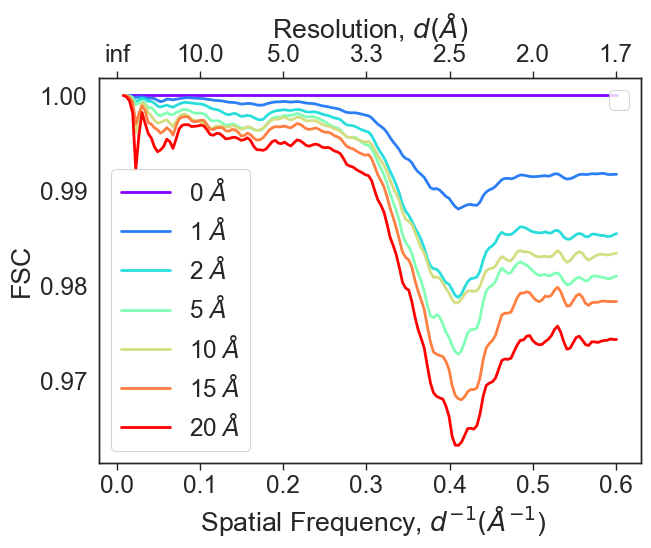

<Figure size 700x500 with 0 Axes>

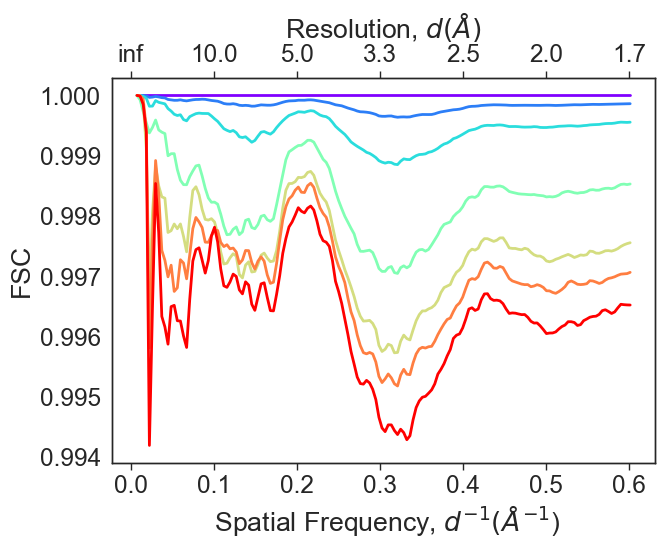

In [8]:
# S3a: refined maps
fig_a_filename = FIGURES / 'figure_S3a.png'
fig_a_filename_str = str(fig_a_filename)
fig_a = pretty_lineplot_multiple_fsc_curves(
    fsc_normal_dict,
    filename=fig_a_filename_str,
    legends=labels,
    linewidth=2, 
    figsize=(7, 5), 
    fontscale=2,
)

print('Saved figures/figure_S3a.png')

# # S3b: blurred maps (no legend in original)
fig_b_filename = FIGURES / 'figure_S3b.png'
fig_b_filename_str = str(fig_b_filename)
fig_b = pretty_lineplot_multiple_fsc_curves(
    fsc_blurred_dict,
    filename=fig_b_filename_str,
    legends=None, 
    linewidth=2, 
    figsize=(7, 5), 
    fontscale=2,
)

print('Saved figures/figure_S3b.png')
